# Does showing a language model the downside change the reward code it writes?

### Preliminary results from the confirmatory campaign

**Status: PRELIMINARY. Nothing in this notebook is a banked result.**

This notebook reads the live campaign archive and reports what has been measured so far. It is
written to be read in order. Each section states its claim first, then shows the evidence, then
says what the evidence does and does not support.

Three things to hold on to before any number appears:

1. **The result the study will report comes from one model, and that model has no data yet.**
   The confirmatory arm is Opus 5. Its final floor jobs are running as this is written. Every
   place that result belongs is marked and will fill in automatically once the records land.
2. **Everything shown here is report-only replication evidence.** It is genuinely informative
   and it is a large part of the contribution, but by the frozen pre-registration it cannot
   state the study's finding.
3. **The estimators here are descriptive.** The registered analysis uses deflated Sharpe,
   interquartile means, seed-block bootstrap and Benjamini-Hochberg correction. Numbers will
   move when that machinery runs.

**How to re-run.** Run every cell top to bottom. The archive load is cached, so only the first
run is slow. Set `FORCE_RELOAD = True` in the setup cell to pick up new records.

## 1. The experiment, before any number

A reader who meets a result before the structure it sits in builds the wrong model of the study
and every later paragraph has to fight it. So the apparatus comes first.

### There are two decision problems, one inside the other

**The inner problem is a Markov decision process.** A reinforcement-learning agent allocates
capital across a panel of equities. Its state is a lagged feature vector plus its previous
weights, its action is a vector of portfolio weights on the simplex, and its reward is whatever
program the designer wrote. The learner is Soft Actor-Critic, held byte-identically fixed across
every condition.

**The outer problem is a bandit whose arms are candidate reward programs.** A language model
proposes reward code, the code is executed inside the training loop, the resulting policy is
scored on a validation window, and the model revises. Thirty candidates per arm, matched.

**Only one thing varies across the experimental conditions: what the designer is shown between
attempts.** That is the identification argument, and it is the reason the inner learner is
frozen.

### The five conditions

| arm | what the reward designer is shown | what it controls for |
|---|---|---|
| `distributional` | six left-tail statistics of the realised return distribution | the treatment |
| `scalar` | one performance number | the comparison |
| `scalar_cvar5` | one number plus a single tail scalar | is it the tail, or the *shape* of the tail |
| `placebo` | one number plus an inert block of matched length | is it information, or just more tokens |
| `placebo_shuffled` | the exact structure of `distributional`, values deranged | is it structure, or content |

**`distributional` against `scalar` is the experiment.** The other three exist so that a
difference, or the absence of one, can be attributed to something specific rather than to
prompt length or formatting.

### What the study reports

Every model climbs one common ladder of seed counts: **30, 100, 189, 279, 340, 403, 568.**

A line banks a rung only when it holds a complete unbroken run of seeds up to that rung on
**every** arm. The reported result is the **lowest rung reached by any model**. Extra seeds on a
model that is already ahead do not raise it.

The campaign stops on a **calendar date, 27 August 2026**, fixed in advance and never contingent
on what the results look like. That is what makes it safe to look at interim numbers: nothing
about data collection can respond to them.

## 2. Setup and provenance

Every number below is read from the archive at run time through the project's own reader,
`src.io.results.load_all`, which validates each record. Nothing is transcribed by hand.

In [1]:
from __future__ import annotations

import json
import pathlib
import sys
import time
import datetime as dt

import numpy as np
import matplotlib.pyplot as plt

# ---- locate the repository root from the notebook's own position -------------------------
HERE = pathlib.Path.cwd()
REPO = next((p for p in [HERE, *HERE.parents] if (p / "src" / "viz" / "style.py").exists()), None)
if REPO is None:
    raise RuntimeError("could not locate the repository root from %s" % HERE)
sys.path.insert(0, str(REPO))

from src.io.results import load_all                      # the ONLY sanctioned record reader
from src.viz.style import (                              # the house figure style
    OKABE_ITO, apply_house_style, iqm_bootstrap_ci, savefig,
)

apply_house_style()

# ---- constants that are FROZEN DESIGN, not choices made here -----------------------------
LADDER      = (30, 100, 189, 279, 340, 403, 568)   # config/preregistration.yaml seeds.tiers
FLOOR       = LADDER[0]                            # the guaranteed common floor rung
STOP_DATE   = "2026-08-27"                         # the exogenous stop
CI_ALPHA    = 0.10                                 # 90% intervals, the registered level
BOOT_REPS   = 4000
PERM_REPS   = 10000

ARCHIVE     = REPO / "outputs" / "campaign_cluster_run4"
FIGDIR      = REPO / "outputs" / "figures_preliminary"
CACHE       = REPO / "outputs" / "notebook_cache" / "preliminary_records.json"
FIGDIR.mkdir(parents=True, exist_ok=True)
CACHE.parent.mkdir(parents=True, exist_ok=True)

FORCE_RELOAD = False        # set True to re-read the archive from disk

NOW = dt.datetime.now(dt.timezone.utc)
print("repository :", REPO)
print("archive    :", ARCHIVE, "(exists:", ARCHIVE.exists(), ")")
print("run at     :", NOW.strftime("%Y-%m-%d %H:%M:%SZ"))

repository : C:\Users\User\Desktop\dissertation_papers\llm-reward-portfolio
archive    : C:\Users\User\Desktop\dissertation_papers\llm-reward-portfolio\outputs\campaign_cluster_run4 (exists: True )
run at     : 2026-08-06 20:36:33Z


In [2]:
def load_archive(force: bool = False) -> dict[tuple[str, str], dict[int, tuple[float, float]]]:
    '''{(line, arm): {seed: (test_sharpe, test_cvar05)}} read through the validating reader.

    Cached to disk because a full validating read of the archive takes several minutes. The cache
    records the record count it was built from, and is REPORTED rather than trusted silently.
    '''
    if CACHE.exists() and not force:
        raw = json.loads(CACHE.read_text(encoding="utf-8"))
        cells = {tuple(k.split("|")): {int(s): tuple(v) for s, v in d.items()}
                 for k, d in raw["cells"].items()}
        print("loaded from CACHE built %s  (%d records, %d cells)"
              % (raw["built_utc"], raw["n_records"], len(cells)))
        print("   -> set FORCE_RELOAD = True to re-read the live archive")
        return cells

    t0 = time.time()
    cells: dict[tuple[str, str], dict[int, tuple[float, float]]] = {}
    for line_dir in sorted(p for p in ARCHIVE.iterdir() if p.is_dir()):
        if not line_dir.name.startswith("test"):
            continue                                  # search records are a different population
        for arm_dir in sorted(p for p in line_dir.iterdir() if p.is_dir()):
            per_seed: dict[int, tuple[float, float]] = {}
            for rec in load_all(arm_dir):
                m = rec.get("metrics", {})
                if m.get("test_sharpe") is None:
                    continue
                per_seed[int(rec["seed"])] = (float(m["test_sharpe"]),
                                              float(m.get("test_cvar05", float("nan"))))
            if per_seed:
                cells[(line_dir.name, arm_dir.name)] = per_seed

    n = sum(len(v) for v in cells.values())
    CACHE.write_text(json.dumps({
        "built_utc": NOW.strftime("%Y-%m-%dT%H:%M:%SZ"), "n_records": n,
        "cells": {f"{a}|{b}": {str(s): list(v) for s, v in d.items()} for (a, b), d in cells.items()},
    }), encoding="utf-8")
    print("read %d records into %d cells in %.0f s  (cached)" % (n, len(cells), time.time() - t0))
    return cells


CELLS = load_archive(force=FORCE_RELOAD)
N_RECORDS = sum(len(v) for v in CELLS.values())
LINES = sorted({line for line, _ in CELLS})
print()
print("test records :", N_RECORDS)
print("lines        :", len(LINES))

loaded from CACHE built 2026-08-06T20:23:20Z  (18419 records, 69 cells)
   -> set FORCE_RELOAD = True to re-read the live archive

test records : 18419
lines        : 12


In [3]:
# ---- the statistics used throughout, defined once ----------------------------------------

def paired(line: str, a: str, b: str, metric: int = 0, max_seed: int | None = None) -> np.ndarray:
    '''Per-seed differences (arm a minus arm b) on the seeds BOTH arms hold.

    metric: 0 = test Sharpe, 1 = test CVaR-5%.  max_seed truncates to a common depth.
    The pairing is the point: the same seed means the same initial weights and the same random
    draws, so the difference is attributable to the reward rather than to the draw.
    '''
    da, db = CELLS.get((line, a)), CELLS.get((line, b))
    if not da or not db:
        return np.array([])
    common = sorted(set(da) & set(db))
    if max_seed is not None:
        common = [s for s in common if s < max_seed]
    return np.array([da[s][metric] - db[s][metric] for s in common], dtype=float)


def boot_ci(x: np.ndarray, *, alpha: float = CI_ALPHA, reps: int = BOOT_REPS, seed: int = 0):
    '''(mean, lo, hi) percentile bootstrap over seeds. Deterministic.'''
    x = np.asarray(x, float)
    x = x[np.isfinite(x)]
    if x.size == 0:
        return (float("nan"),) * 3
    if x.size < 2:
        return float(x[0]), float(x[0]), float(x[0])
    rng = np.random.default_rng(seed)
    draws = rng.integers(0, x.size, size=(reps, x.size))
    means = x[draws].mean(axis=1)
    lo, hi = np.quantile(means, [alpha / 2, 1 - alpha / 2])
    return float(x.mean()), float(lo), float(hi)


def signflip_p(x: np.ndarray, *, reps: int = PERM_REPS, seed: int = 0) -> float:
    '''Two-sided paired sign-flip permutation p-value. Exact under a symmetric null.

    This is the paired analogue of the permutation logic the design uses. It makes no normality
    assumption, which matters because per-seed scores here are heavy-tailed.
    '''
    x = np.asarray(x, float)
    x = x[np.isfinite(x)]
    if x.size < 2:
        return float("nan")
    obs = abs(x.mean())
    rng = np.random.default_rng(seed)
    signs = rng.choice(np.array([-1.0, 1.0]), size=(reps, x.size))
    null = np.abs((signs * x).mean(axis=1))
    return float((1 + int((null >= obs).sum())) / (reps + 1))


def benjamini_hochberg(p: np.ndarray) -> np.ndarray:
    '''BH step-up adjusted p-values, controlling the false discovery rate across a family.'''
    p = np.asarray(p, float)
    n = p.size
    order = np.argsort(p)
    adj = p[order] * n / (np.arange(n) + 1)
    adj = np.minimum.accumulate(adj[::-1])[::-1]
    out = np.empty(n)
    out[order] = np.clip(adj, 0.0, 1.0)
    return out


def pretty(line: str) -> str:
    if line == "test":
        return "OPUS 5  (confirmatory)"
    if line == "test_h3_singleshot":
        return "h3_singleshot"
    return line.replace("test_leg_", "")


# ---- the REGISTERED arm roster per line ---------------------------------------------------
# An arm that has produced NO records does not appear in the archive at all. Counting only the
# arms that are present would report a line as having banked a rung it has not: the Opus line
# holds 30 seeds on eighteen arms and ZERO on the two that matter, and reading depth from the
# archive alone would score it 30. Depth is therefore measured against the roster, never against
# what happens to be on disk.
CORE_ARMS = ("distributional", "scalar", "scalar_cvar5", "placebo", "placebo_shuffled",
             "random_search", "bayes_opt", "cma_es", "tpe")
LEG_ARMS  = ("distributional", "scalar", "scalar_cvar5", "placebo", "placebo_shuffled")


def roster(line: str) -> list[str]:
    '''Every arm the line is REGISTERED to produce, present in the archive or not.'''
    if line == "test":
        return list(CORE_ARMS) + sorted(a for l, a in CELLS if l == "test" and a.startswith("baseline_"))
    if line == "test_h3_singleshot":
        return ["distributional"]
    return list(LEG_ARMS)


def depth(line: str, arm: str) -> int:
    return len(CELLS.get((line, arm), {}))


print("statistics defined:  paired  boot_ci  signflip_p  benjamini_hochberg  roster  depth")
print("intervals are %d%% percentile bootstrap over seeds, %d resamples, deterministic"
      % (round((1 - CI_ALPHA) * 100), BOOT_REPS))

statistics defined:  paired  boot_ci  signflip_p  benjamini_hochberg  roster  depth
intervals are 90% percentile bootstrap over seeds, 4000 resamples, deterministic


### What was read

The table below is the audit trail for everything that follows. A reader can check any number in
this notebook against the archive by going to the line and arm named here.

In [4]:
rows = []
for line in LINES:
    arms = roster(line)
    depths = {a: depth(line, a) for a in arms}
    banked = min(depths.values()) if depths else 0
    rung = max([r for r in LADDER if r <= banked], default=0)
    empty = [a for a, n in depths.items() if n == 0]
    rows.append((pretty(line), len(arms), sum(depths.values()), banked, rung, empty))

w = max(len(r[0]) for r in rows) + 2
print("%-*s %5s %9s %8s %7s   %s" % (w, "line", "arms", "records", "min arm", "rung", "arms with NO data"))
print("-" * (w + 60))
for name, n_arms, n_rec, banked, rung, empty in sorted(rows, key=lambda r: -r[3]):
    print("%-*s %5d %9d %8d %7s   %s"
          % (w, name, n_arms, n_rec, banked, rung if rung else "--",
             ", ".join(empty) if empty else "-"))
print("-" * (w + 60))
print("%-*s %5s %9d" % (w, "TOTAL", "", N_RECORDS))

FULL_LOOP = [r for r in rows if r[0] != "h3_singleshot"]
COMMON_RUNG = min((r[4] for r in FULL_LOOP), default=0)
print()
print("COMMON RUNG (the number the study reports) :", COMMON_RUNG)
print("   the MINIMUM over the %d full-loop lines, so it is set by the slowest, never the fastest"
      % len(FULL_LOOP))
holding = [r[0] for r in FULL_LOOP if r[4] == COMMON_RUNG]
print("   currently held down by:", ", ".join(holding))

line                      arms   records  min arm    rung   arms with NO data
------------------------------------------------------------------------------------
h3_singleshot                1       568      568     568   -
gemini_2_5_flash             5      2840      568     568   -
gpt_5_6_luna                 5      2840      568     568   -
qwen3_5_9b                   5      2840      568     568   -
sonnet_5                     5      2840      568     568   -
haiku_4_5                    5      2832      566     403   -
kimi_k3                      5      1654      327     279   -
qwen3_6_27b                  5      1015      202     189   -
deepseek_v4_pro              5       150       30      30   -
glm_5_2                      5       150       30      30   -
nemotron_3_super             5       150       30      30   -
OPUS 5  (confirmatory)      20       540        0      --   distributional, scalar
------------------------------------------------------------------------

**Read the last number first. The common rung is what the study reports, and it is currently
zero.**

That is not a failure. It is the design working exactly as intended. Ten of the twelve lines have
already completed the floor. The rung sits at zero because the Opus line has not, and the rule is
a minimum rather than an average. A single incomplete line holds the reported figure down no
matter how far ahead everything else runs.

Notice how uneven the depth column is. Four lines carry 568 seeds while three carry 30. That is a
scheduling outcome, not a design choice, and it is the reason every cross-model comparison below
is truncated to a common depth before it is computed.

## 3. Where the campaign stands

**The fleet is deep on some models and shallow on others, and the reported rung is set by the
shallowest.** The figure makes the gap between what has been computed and what can be claimed
visible in one panel.

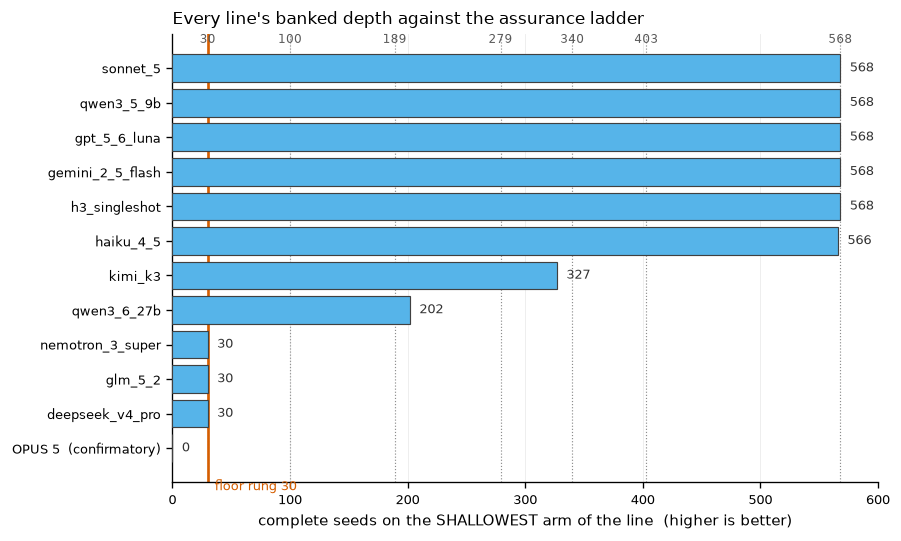

In [5]:
fig, ax = plt.subplots(figsize=(7.4, 4.4))

order = sorted(rows, key=lambda r: r[3])
names = [r[0] for r in order]
banked = [r[3] for r in order]

bars = ax.barh(names, banked, color=OKABE_ITO["skyblue"], edgecolor="0.25", linewidth=0.7, zorder=3)
for r in LADDER:
    ax.axvline(r, color="0.55", lw=0.7, ls=":", zorder=1)
    ax.text(r, len(names) - 0.35, str(r), ha="center", va="bottom", fontsize=7, color="0.35")

for b, v in zip(bars, banked):
    ax.text(v + 8, b.get_y() + b.get_height() / 2, str(v), va="center", fontsize=7.5, color="0.2")

ax.axvline(FLOOR, color=OKABE_ITO["vermillion"], lw=1.6, zorder=2)
ax.text(FLOOR + 6, -0.9, "floor rung 30", color=OKABE_ITO["vermillion"], fontsize=8, va="top")

ax.set_xlabel("complete seeds on the SHALLOWEST arm of the line  (higher is better)")
ax.set_xlim(0, 600)
ax.set_title("Every line's banked depth against the assurance ladder", loc="left")
ax.grid(axis="y", visible=False)
savefig(fig, FIGDIR / "F1_campaign_progress.png")
plt.show()

**Figure 1. Banked depth per line against the frozen assurance ladder.** Each bar is the number
of complete seeds held by the *shallowest* arm on that line, which is what determines whether the
line has banked a rung. Dotted verticals mark the seven registered rungs. The red line marks the
floor at thirty seeds.

**What to conclude.** Ten lines have cleared the floor and four are near the top of the ladder,
yet the study still reports rung zero, because the Opus line has not finished. The distance
between the tallest bar and the reported rung is the cost of the minimum rule, and it is
deliberate. The rule exists so that a headline number can never rest on whichever model happened
to get the most machines.

## 4. The confirmatory result

**This is the only result the study is permitted to report, and it is not in yet.**

The frozen pre-registration scopes the confirmatory look to `confirmatory_opus_arm_at_achieved_rung`.
One model sits in that seat, Opus 5, and the reason is on record. A null measured on a weak model
is a statement about the model rather than about the feedback channel. The leg evidence later in
this notebook demonstrates that concern rather than merely asserting it.

The cell below reads the archive and fills this section in automatically. Until the records land
it prints what is outstanding.

In [6]:
d_op = CELLS.get(("test", "distributional"), {})
s_op = CELLS.get(("test", "scalar"), {})
common_op = sorted(set(d_op) & set(s_op))

print("=" * 74)
print("CONFIRMATORY ARM: Opus 5   (line 'test' / c1)")
print("=" * 74)
print("  distributional records : %d / %d" % (len(d_op), FLOOR))
print("  scalar records         : %d / %d" % (len(s_op), FLOOR))
print("  paired seeds available : %d" % len(common_op))
print()

if len(common_op) >= 5:
    for metric, label, unit in ((0, "Sharpe", "Sharpe units"), (1, "CVaR-5%", "daily return")):
        d = paired("test", "distributional", "scalar", metric=metric, max_seed=FLOOR)
        m, lo, hi = boot_ci(d)
        pt, plo, phi = iqm_bootstrap_ci(d, alpha=CI_ALPHA, reps=BOOT_REPS)
        p = signflip_p(d)
        print("  %-9s  n=%d   mean %+0.4f [%+0.4f, %+0.4f]   IQM %+0.4f [%+0.4f, %+0.4f]   p=%0.4f  (%s)"
              % (label, d.size, m, lo, hi, pt, plo, phi, p, unit))
    print()
    print("  ^ THIS IS THE RESULT. Everything else in this notebook is replication evidence.")
else:
    print("  >>> AWAITING DATA <<<")
    print()
    print("  The floor jobs for these two arms are the H2 pair test, submitted as eight arrays.")
    print("  They run as ONE interleaved unit so both arms share identical seeds, which is what")
    print("  makes the comparison paired. Expected duration is 8.4 to 9.2 hours from dispatch,")
    print("  measured from the previous identical job shape.")
    print()
    print("  When the records land, re-run this notebook with FORCE_RELOAD = True and this panel,")
    print("  the Opus row in Figure 2, and the Opus row in Figure 3 all populate automatically.")

CONFIRMATORY ARM: Opus 5   (line 'test' / c1)
  distributional records : 0 / 30
  scalar records         : 0 / 30
  paired seeds available : 0

  >>> AWAITING DATA <<<

  The floor jobs for these two arms are the H2 pair test, submitted as eight arrays.
  They run as ONE interleaved unit so both arms share identical seeds, which is what
  makes the comparison paired. Expected duration is 8.4 to 9.2 hours from dispatch,
  measured from the previous identical job shape.

  When the records land, re-run this notebook with FORCE_RELOAD = True and this panel,
  the Opus row in Figure 2, and the Opus row in Figure 3 all populate automatically.


**How to read this section tomorrow, when it is populated.**

The number to look at is the paired difference and its interval, not the p-value. Three readings
are possible and they are not the same thing.

- **The interval sits clearly on one side of zero.** The channel changed the outcome, in the
  direction of the sign, on this model, at this rung.
- **The interval straddles zero and is narrow.** Evidence of a bounded effect. This is the
  pre-registered prediction, and it is a positive finding rather than a failure, because a tight
  interval around zero rules out effects large enough to matter.
- **The interval straddles zero and is wide.** Inconclusive at this rung. Not evidence of absence.
  The registered analysis has an explicit branch for this, and at thirty seeds it is the most
  likely outcome, because the power calculation puts the seeds needed to declare equivalence at
  the registered margin at roughly one hundred and seventy-three.

**Do not read the point estimate without the interval.** At thirty seeds the seed-to-seed noise
on this contrast was measured at 0.369 Sharpe units in the pilot, which is far larger than the
effect anyone expects.

## 5. The same question, answered on ten other models

**There is no single effect of tail feedback. The direction depends on the model, and that is
itself the most interesting thing measured so far.**

Ten replication models run the identical five arms. They cannot state the study's result, but
they answer the same question ten more times, and with far more seeds than the confirmatory arm
will have for weeks.

Every contrast below is truncated to **seeds 0 to 29**, so a model with 568 seeds is compared on
the same basis as one with 30. Comparing a deep estimate against a shallow one would confound the
effect with the amount of evidence.

In [7]:
LEGS = [l for l in LINES if l.startswith("test_leg_")]

res = []
for line in LEGS:
    d_sh = paired(line, "distributional", "scalar", metric=0, max_seed=FLOOR)
    d_cv = paired(line, "distributional", "scalar", metric=1, max_seed=FLOOR)
    if d_sh.size < 5:
        continue
    m, lo, hi = boot_ci(d_sh)
    cm, clo, chi = boot_ci(d_cv)
    res.append({
        "line": pretty(line), "n": int(d_sh.size),
        "sh": m, "sh_lo": lo, "sh_hi": hi, "sh_p": signflip_p(d_sh),
        "cv": cm, "cv_lo": clo, "cv_hi": chi, "cv_p": signflip_p(d_cv),
        "d_sh": d_sh, "d_cv": d_cv,
    })

res.sort(key=lambda r: r["sh"])
for key in ("sh", "cv"):
    adj = benjamini_hochberg(np.array([r[f"{key}_p"] for r in res]))
    for r, a in zip(res, adj):
        r[f"{key}_q"] = float(a)

print("H2 PAIRED CONTRAST  (distributional minus scalar), seeds 0-%d, %d%% bootstrap CI"
      % (FLOOR - 1, round((1 - CI_ALPHA) * 100)))
print("BH q-values control the false discovery rate across the %d-leg family" % len(res))
print()
print("%-20s %3s  %-26s %8s %8s   %s" % ("model", "n", "d Sharpe [90% CI]", "p", "q(BH)", "reading"))
print("-" * 96)
for r in res:
    sig = r["sh_lo"] * r["sh_hi"] > 0
    reading = ("tail feedback WORSE" if r["sh"] < 0 else "tail feedback BETTER") if sig else "no detectable difference"
    print("%-20s %3d  %+7.4f [%+7.4f,%+7.4f] %8.4f %8.4f   %s"
          % (r["line"], r["n"], r["sh"], r["sh_lo"], r["sh_hi"], r["sh_p"], r["sh_q"], reading))

# The interval and the permutation test are two different questions and at thirty seeds they can
# disagree. Saying so is more useful than picking whichever looks tidier, so any row where the
# 90% interval excludes zero while the BH-adjusted p does not clear 0.05 is named explicitly.
clash = [r for r in res if (r["sh_lo"] * r["sh_hi"] > 0) != (r["sh_q"] < 0.05)]
print()
if clash:
    print("!! the interval and the corrected permutation test DISAGREE on %d row(s):" % len(clash))
    for r in clash:
        print("   %-20s CI excludes zero = %-5s   BH q = %.4f  -> treat as SUGGESTIVE, not detected"
              % (r["line"], str(r["sh_lo"] * r["sh_hi"] > 0), r["sh_q"]))
    print("   at n=30 this is expected. The stricter of the two governs.")
else:
    print("the interval and the corrected permutation test agree on every row.")

H2 PAIRED CONTRAST  (distributional minus scalar), seeds 0-29, 90% bootstrap CI
BH q-values control the false discovery rate across the 10-leg family

model                  n  d Sharpe [90% CI]                 p    q(BH)   reading
------------------------------------------------------------------------------------------------
gemini_2_5_flash      30  -1.0150 [-1.1125,-0.9141]   0.0001   0.0002   tail feedback WORSE
qwen3_5_9b            30  -0.7587 [-0.8462,-0.6767]   0.0001   0.0002   tail feedback WORSE
gpt_5_6_luna          30  -0.2467 [-0.3081,-0.1864]   0.0001   0.0002   tail feedback WORSE
sonnet_5              30  -0.0685 [-0.1097,-0.0298]   0.0106   0.0212   tail feedback WORSE
deepseek_v4_pro       30  -0.0154 [-0.0413,+0.0112]   0.3548   0.4146   no detectable difference
kimi_k3               30  +0.0028 [-0.0387,+0.0488]   0.9229   0.9229   no detectable difference
qwen3_6_27b           30  +0.0458 [-0.0186,+0.1082]   0.2602   0.3717   no detectable difference
nemotron_3_s

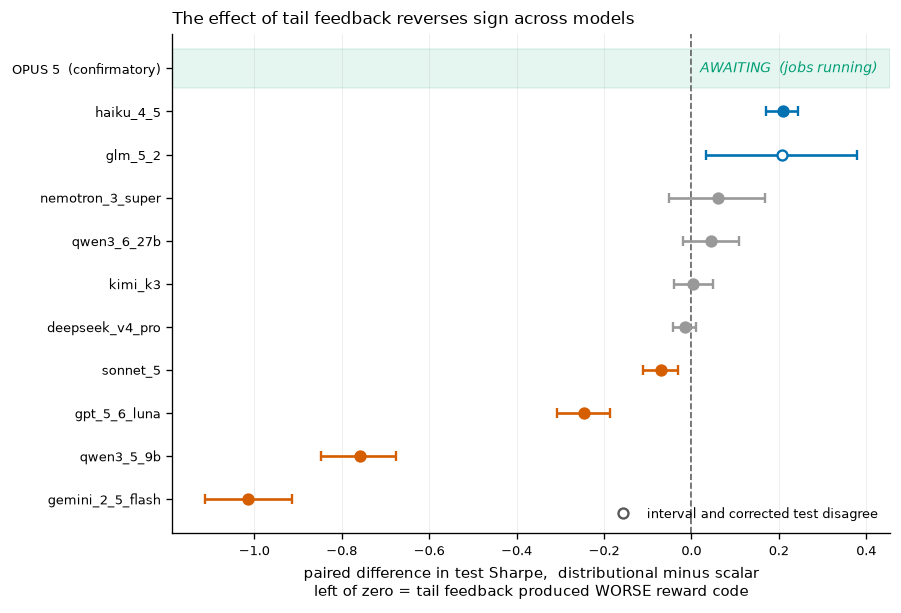

In [8]:
fig, ax = plt.subplots(figsize=(7.4, 5.0))

labels, xs, los, his, cols, solid = [], [], [], [], [], []
for r in res:
    labels.append(r["line"])
    xs.append(r["sh"]); los.append(r["sh"] - r["sh_lo"]); his.append(r["sh_hi"] - r["sh"])
    sig = r["sh_lo"] * r["sh_hi"] > 0
    cols.append(OKABE_ITO["vermillion"] if (sig and r["sh"] < 0)
                else OKABE_ITO["blue"] if sig else OKABE_ITO["grey"])
    # HOLLOW marks DISAGREEMENT between the interval and the corrected permutation test, so the
    # figure cannot read as more confident than the text. A row where both procedures agree is
    # filled whether or not the effect is detected: a non-significant row is not a disagreement,
    # and drawing it hollow would make the legend say something false about it.
    solid.append(sig == (r["sh_q"] < 0.05))

# the confirmatory arm gets a reserved row whether or not it has data yet
labels.append("OPUS 5  (confirmatory)")
has_opus = len(common_op) >= 5
if has_opus:
    m, lo, hi = boot_ci(paired("test", "distributional", "scalar", 0, FLOOR))
    xs.append(m); los.append(m - lo); his.append(hi - m)
else:
    xs.append(np.nan); los.append(np.nan); his.append(np.nan)
cols.append(OKABE_ITO["green"]); solid.append(True)

y = np.arange(len(labels))
ax.axvline(0.0, color="0.35", lw=1.0, ls="--", zorder=1)
for i, (x, l, h, c, f) in enumerate(zip(xs, los, his, cols, solid)):
    if not np.isfinite(x):
        continue
    ax.errorbar(x, i, xerr=[[l], [h]], fmt="o", color=c, ecolor=c,
                markerfacecolor=(c if f else "white"), markeredgewidth=1.4,
                elinewidth=1.6, capsize=3, markersize=6.0, zorder=3)

if any(not f for f in solid):
    ax.plot([], [], "o", color="0.35", markerfacecolor="white", markeredgewidth=1.4,
            label="interval and corrected test disagree")
    ax.legend(loc="lower right")

if not has_opus:
    ax.axhspan(len(labels) - 1.45, len(labels) - 0.55, color=OKABE_ITO["green"], alpha=0.10, zorder=0)
    ax.text(0.02, len(labels) - 1, "AWAITING  (jobs running)", color=OKABE_ITO["green"],
            fontsize=8.5, va="center", ha="left", style="italic")

ax.set_yticks(y); ax.set_yticklabels(labels)
ax.set_ylim(-0.8, len(labels) - 0.2)
ax.set_xlabel("paired difference in test Sharpe,  distributional minus scalar\n"
              "left of zero = tail feedback produced WORSE reward code")
ax.set_title("The effect of tail feedback reverses sign across models", loc="left")
ax.grid(axis="y", visible=False)
savefig(fig, FIGDIR / "F2_h2_forest_sharpe.png")
plt.show()

**Figure 2. Paired effect of tail feedback on out-of-sample Sharpe, one row per model, thirty
seeds each.** Points are mean paired differences with ninety per cent bootstrap intervals over
seeds. Red marks a detected loss, blue a detected gain, grey an interval covering zero. The
reserved bottom row is the confirmatory arm.

**What to conclude.** The rows do not share a sign. Four models are made worse by tail feedback,
two are made better, and four show no detectable difference. Averaging them into a single number
would destroy the finding rather than summarise it.

**One row is weaker than its colour suggests, and the cell above names it.** For `glm_5_2` the
interval excludes zero but the multiplicity-corrected permutation test does not clear the
conventional threshold. Two reasonable procedures disagree, which is what thirty seeds buys you.
Read that row as suggestive rather than established, and take the stricter of the two.

### The mechanism this points at

**Look at the two Qwen rows.** They are the same family from the same provider at the same
quantisation, differing only in size, and they are in the design specifically as a controlled
capability contrast. The nine-billion model is near the bottom of the panel. The twenty-seven
billion model is in the indistinguishable middle.

That is the numeracy-bottleneck hypothesis showing up where the design predicted it. The
mechanism is not that tail feedback is harmful. It is that a designer who cannot read six small
floating-point numbers reliably does worse when handed six of them than when handed one, because
the extra numbers are noise to it rather than signal. Independent evidence supports the premise:
measured authoring reliability for this model is around seventeen per cent against eighty-three
per cent for its larger sibling.

`gemini_2_5_flash` sits at the extreme of the same pattern and is worth looking at in absolute
terms rather than as a difference, which is what the next figure does.

**The honest counter-explanation, which this figure cannot rule out.** The contrast is between
two *authoring loops*, not between two prompts held otherwise equal. A model that writes worse
code under tail feedback may be failing at reading, at using, or at expressing what it read. The
responsiveness and mediation instruments in the mechanism kernel are what separate those, and
they are not in this notebook.

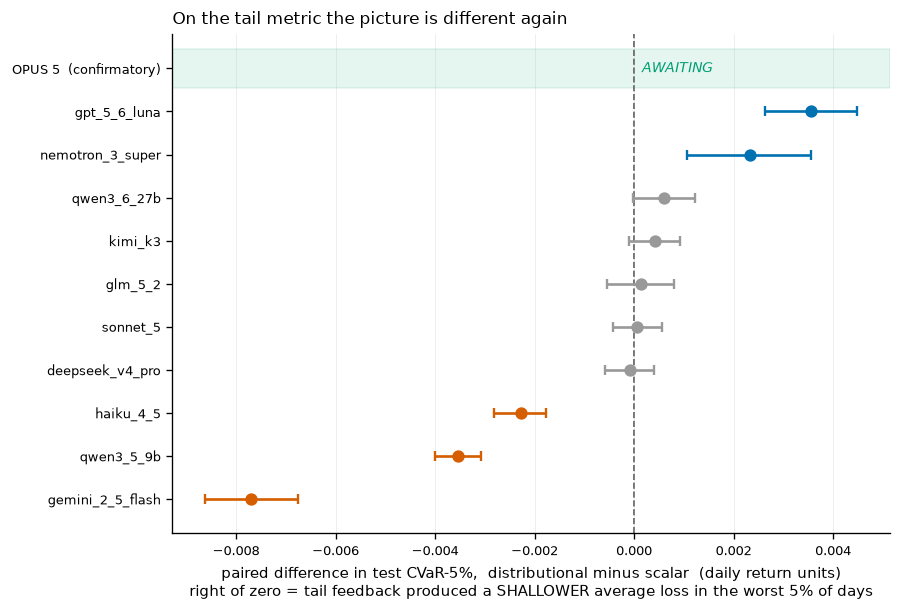

In [9]:
fig, ax = plt.subplots(figsize=(7.4, 5.0))

order_cv = sorted(res, key=lambda r: r["cv"])
labels = [r["line"] for r in order_cv]
ax.axvline(0.0, color="0.35", lw=1.0, ls="--", zorder=1)
for i, r in enumerate(order_cv):
    sig = r["cv_lo"] * r["cv_hi"] > 0
    c = OKABE_ITO["vermillion"] if (sig and r["cv"] < 0) else OKABE_ITO["blue"] if sig else OKABE_ITO["grey"]
    filled = (sig == (r["cv_q"] < 0.05))       # hollow = the two procedures DISAGREE
    ax.errorbar(r["cv"], i, xerr=[[r["cv"] - r["cv_lo"]], [r["cv_hi"] - r["cv"]]],
                fmt="o", color=c, ecolor=c, markerfacecolor=(c if filled else "white"),
                markeredgewidth=1.4, elinewidth=1.6, capsize=3, markersize=6.0, zorder=3)

labels.append("OPUS 5  (confirmatory)")
if has_opus:
    m, lo, hi = boot_ci(paired("test", "distributional", "scalar", 1, FLOOR))
    ax.errorbar(m, len(labels) - 1, xerr=[[m - lo], [hi - m]], fmt="o",
                color=OKABE_ITO["green"], ecolor=OKABE_ITO["green"],
                elinewidth=1.6, capsize=3, markersize=5.5, zorder=3)
else:
    ax.axhspan(len(labels) - 1.45, len(labels) - 0.55, color=OKABE_ITO["green"], alpha=0.10, zorder=0)
    ax.text(0.0, len(labels) - 1, "  AWAITING", color=OKABE_ITO["green"], fontsize=8.5,
            va="center", ha="left", style="italic")

ax.set_yticks(np.arange(len(labels))); ax.set_yticklabels(labels)
ax.set_ylim(-0.8, len(labels) - 0.2)
ax.set_xlabel("paired difference in test CVaR-5%,  distributional minus scalar  (daily return units)\n"
              "right of zero = tail feedback produced a SHALLOWER average loss in the worst 5% of days")
ax.set_title("On the tail metric the picture is different again", loc="left")
ax.grid(axis="y", visible=False)
savefig(fig, FIGDIR / "F3_h2_forest_cvar.png")
plt.show()

**Figure 3. The same paired contrast on the tail metric, CVaR at the five per cent level.**
Units are daily return, so a value of 0.003 is thirty basis points of average daily loss in the
worst one day in twenty. Right of zero means the tail-fed arm lost less.

**What to conclude, and it is the reason this figure exists.** The ordering here is not the
ordering in Figure 2. A model can be pushed toward worse risk-adjusted return while its tail
improves, or the reverse. That is exactly why the design registers **two co-primary tests**
rather than one, and why declaring the study on Sharpe alone would have been a choice that
smuggled in an assumption about what the channel is supposed to move.

**The magnitudes deserve a sceptical eye.** These differences are in the third and fourth decimal
place of a daily return. They are statistically detectable at this depth on several models, which
is a statement about precision rather than about importance. Whether a three-basis-point change
in average tail loss matters is a question for the practitioner section, not for the estimator.

## 6. Differences hide the thing that matters most

**Two of the ten models do not merely do worse under tail feedback. They produce reward code that
loses money.** A difference of minus one Sharpe unit reads very differently once you see that it
runs from a healthy positive level to a negative one.

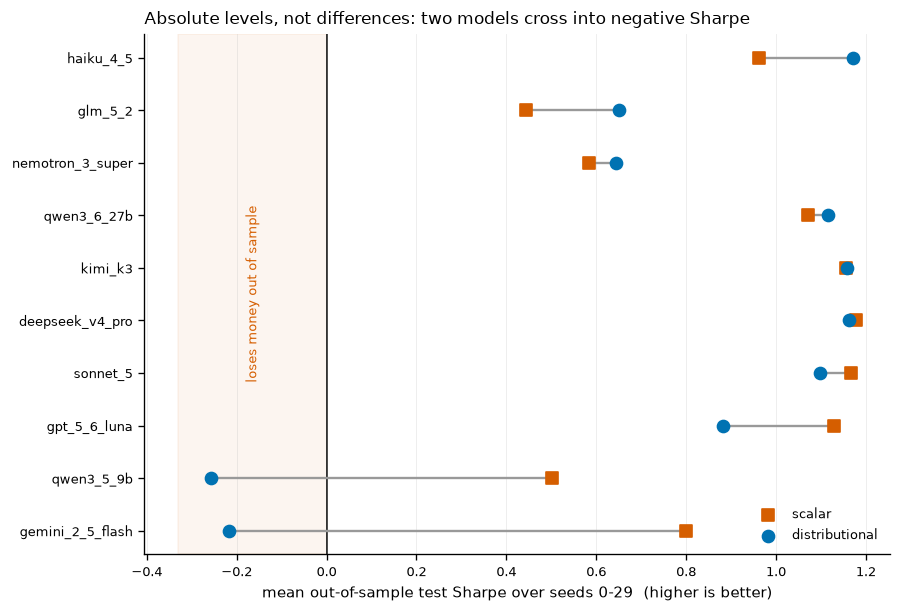

  gemini_2_5_flash     scalar +0.799  ->  distributional -0.216   CROSSES ZERO
  qwen3_5_9b           scalar +0.501  ->  distributional -0.258   CROSSES ZERO


In [10]:
fig, ax = plt.subplots(figsize=(7.4, 5.0))

lv = []
for line in LEGS:
    dd, ds = CELLS.get((line, "distributional")), CELLS.get((line, "scalar"))
    if not dd or not ds:
        continue
    common = sorted(s for s in (set(dd) & set(ds)) if s < FLOOR)
    if len(common) < 5:
        continue
    lv.append((pretty(line),
               float(np.mean([ds[s][0] for s in common])),
               float(np.mean([dd[s][0] for s in common]))))
lv.sort(key=lambda t: t[2] - t[1])

for i, (name, s_lvl, d_lvl) in enumerate(lv):
    worse = d_lvl < s_lvl
    ax.plot([s_lvl, d_lvl], [i, i], color="0.6", lw=1.4, zorder=2)
    ax.scatter(s_lvl, i, s=46, color=OKABE_ITO["vermillion"], marker="s",
               zorder=3, label="scalar" if i == 0 else None)
    ax.scatter(d_lvl, i, s=52, color=OKABE_ITO["blue"], marker="o",
               zorder=4, label="distributional" if i == 0 else None)

ax.axvline(0.0, color="0.2", lw=1.2, zorder=1)
xlo = ax.get_xlim()[0]
ax.axvspan(xlo, 0.0, color=OKABE_ITO["vermillion"], alpha=0.06, zorder=0)
# Placed INSIDE the band and rotated. At the top of the axes it overprinted the title.
ax.text(xlo / 2, (len(lv) - 1) / 2, "loses money out of sample", rotation=90,
        ha="center", va="center", fontsize=8, color=OKABE_ITO["vermillion"])

ax.set_yticks(np.arange(len(lv))); ax.set_yticklabels([t[0] for t in lv])
ax.set_xlabel("mean out-of-sample test Sharpe over seeds 0-29  (higher is better)")
ax.set_title("Absolute levels, not differences: two models cross into negative Sharpe", loc="left")
ax.legend(loc="lower right")
ax.grid(axis="y", visible=False)
savefig(fig, FIGDIR / "F4_levels_dumbbell.png")
plt.show()

for name, s_lvl, d_lvl in lv:
    if d_lvl < 0 <= s_lvl:
        print("  %-20s scalar %+0.3f  ->  distributional %+0.3f   CROSSES ZERO" % (name, s_lvl, d_lvl))

**Figure 4. Where each model's two arms actually sit, rather than how far apart they are.**
Squares are the scalar-fed arm, circles the tail-fed arm, and the connecting line is the effect
from Figure 2. The shaded region is negative Sharpe, meaning the strategy lost money out of
sample.

**What to conclude.** For most models both arms sit in a tight band a little above one, which is
the signature of a designer that has found a competent reward whatever it was shown. Two models
break that pattern, and both break it in the same direction and in the same way: the scalar arm
is fine and the tail-fed arm is not.

**This is the strongest single piece of mechanism evidence available so far.** The failure is not
a small degradation spread evenly across models. It is concentrated, it is large, and it lands on
exactly the models the capability argument predicts. A story in which tail feedback is mildly
unhelpful cannot produce this shape. A story in which some designers cannot parse what they are
handed can.

**What would falsify it.** If a high-capability model showed the same collapse, capability would
stop explaining it. Nothing in the panel does that yet, and the confirmatory arm is the strongest
available test of it, since Opus sits at the top of the capability range.

## 7. Does the estimate settle, or is it an artefact of where we stopped?

**A single number at the end of a run says nothing about whether that number was stable.** This
section answers the question directly, because the ladder is cumulative and paired, so every
prefix of seeds is itself a complete valid study. Most published work cannot show this.

**Three disciplines apply to the figure below and none of them is optional.**

1. **Seeds appear in the registered order and are never sorted.** Sorting would turn the curve
   into a selection artefact.
2. **The stopping rule is exogenous.** The campaign ends on 27 August 2026 by calendar, decided
   in advance.
3. **No inference was drawn at any prefix.** The curve is shown so a reader can see the noise, not
   so anyone can choose where to stop.

Without all three this exhibit would invite exactly the optional-stopping reasoning the
pre-registration forbids.

lines deep enough to show a trajectory (>=200 paired seeds): gemini_2_5_flash, gpt_5_6_luna, haiku_4_5, kimi_k3, qwen3_5_9b, qwen3_6_27b, sonnet_5


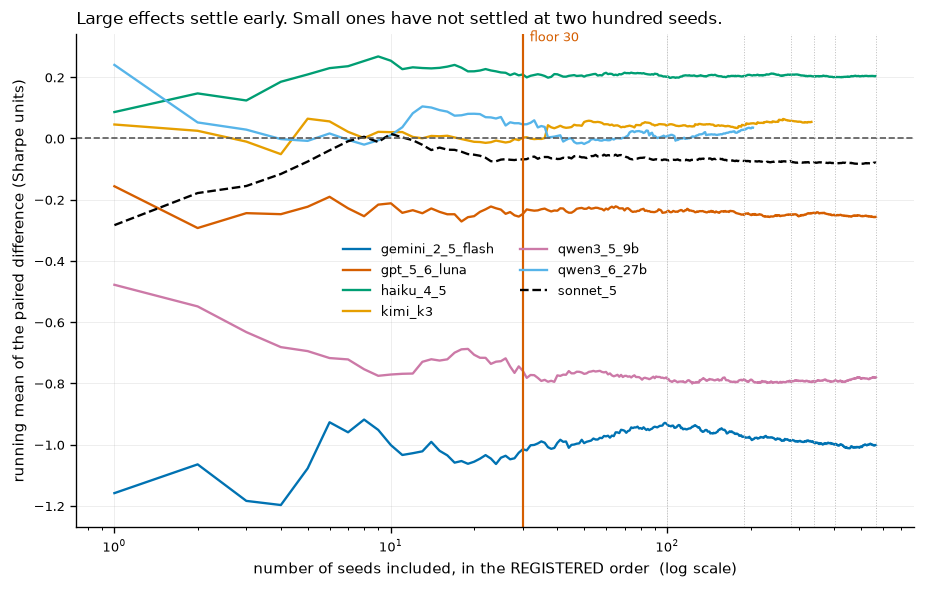

model                    n  POINT estimate                   90% interval WIDTH              
                                 at 30    at full     drift       at 30    at full    shrink
------------------------------------------------------------------------------------------------
gemini_2_5_flash       568     -1.0150    -1.0012   +0.0138      0.1984     0.0478      4.1x
gpt_5_6_luna           568     -0.2467    -0.2565   -0.0097      0.1217     0.0303      4.0x
haiku_4_5              566     +0.2088    +0.2034   -0.0054      0.0733     0.0197      3.7x
kimi_k3                332     +0.0028    +0.0539   +0.0511      0.0875     0.0414      2.1x
qwen3_5_9b             568     -0.7587    -0.7803   -0.0216      0.1695     0.0426      4.0x
qwen3_6_27b            204     +0.0458    +0.0353   -0.0105      0.1268     0.0707      1.8x
sonnet_5               568     -0.0685    -0.0793   -0.0108      0.0799     0.0183      4.4x

models whose running estimate STILL CHANGES SIGN after the floor

In [11]:
DEEP = [l for l in LEGS if min(depth(l, "distributional"), depth(l, "scalar")) >= 200]
print("lines deep enough to show a trajectory (>=200 paired seeds):",
      ", ".join(pretty(l) for l in sorted(DEEP)) or "none")

fig, ax = plt.subplots(figsize=(7.6, 4.8))

# EIGHT distinct colours plus a linestyle cycle. A six-colour palette WRAPPED at the seventh line
# and drew sonnet_5 in gemini's blue, which made two opposite-signed curves look like one model.
SERIES = [(OKABE_ITO["blue"], "-"), (OKABE_ITO["vermillion"], "-"), (OKABE_ITO["green"], "-"),
          (OKABE_ITO["orange"], "-"), (OKABE_ITO["purple"], "-"), (OKABE_ITO["skyblue"], "-"),
          (OKABE_ITO["black"], "--"), (OKABE_ITO["grey"], "--")]
assert len(SERIES) >= len(DEEP), "extend SERIES: %d lines, %d styles" % (len(DEEP), len(SERIES))

for k, line in enumerate(sorted(DEEP)):
    dd, ds = CELLS[(line, "distributional")], CELLS[(line, "scalar")]
    seeds = sorted(set(dd) & set(ds))                 # REGISTERED ORDER, never sorted by value
    diffs = np.array([dd[s][0] - ds[s][0] for s in seeds], float)
    running = np.cumsum(diffs) / np.arange(1, diffs.size + 1)
    col, sty = SERIES[k]
    ax.plot(np.arange(1, diffs.size + 1), running, lw=1.4, color=col, ls=sty, label=pretty(line))

ax.axhline(0.0, color="0.35", lw=1.0, ls="--")
for r in LADDER:
    ax.axvline(r, color="0.75", lw=0.6, ls=":")
ax.axvline(FLOOR, color=OKABE_ITO["vermillion"], lw=1.3)
ax.text(FLOOR * 1.06, ax.get_ylim()[1] * 0.93, "floor 30", color=OKABE_ITO["vermillion"], fontsize=8)

ax.set_xscale("log")
ax.set_xlabel("number of seeds included, in the REGISTERED order  (log scale)")
ax.set_ylabel("running mean of the paired difference (Sharpe units)")
ax.set_title("Large effects settle early. Small ones have not settled at two hundred seeds.", loc="left")
ax.legend(loc="best", ncols=2)
savefig(fig, FIGDIR / "F5_seed_trajectory.png")
plt.show()

print("%-20s %5s  %-32s %-32s" % ("model", "n", "POINT estimate", "90% interval WIDTH"))
print("%-20s %5s  %10s %10s %9s  %10s %10s %9s"
      % ("", "", "at 30", "at full", "drift", "at 30", "at full", "shrink"))
print("-" * 96)
for line in sorted(DEEP):
    dd, ds = CELLS[(line, "distributional")], CELLS[(line, "scalar")]
    seeds = sorted(set(dd) & set(ds))
    diffs = np.array([dd[s][0] - ds[s][0] for s in seeds], float)
    _, lo30, hi30 = boot_ci(diffs[:FLOOR])
    _, loN, hiN = boot_ci(diffs)
    w30, wN = hi30 - lo30, hiN - loN
    print("%-20s %5d  %+10.4f %+10.4f %+9.4f  %10.4f %10.4f %8.1fx"
          % (pretty(line), diffs.size, diffs[:FLOOR].mean(), diffs.mean(),
             diffs.mean() - diffs[:FLOOR].mean(), w30, wN, w30 / wN if wN else float("nan")))

signflips = []
for line in sorted(DEEP):
    dd, ds = CELLS[(line, "distributional")], CELLS[(line, "scalar")]
    seeds = sorted(set(dd) & set(ds))
    diffs = np.array([dd[s][0] - ds[s][0] for s in seeds], float)
    run = np.cumsum(diffs) / np.arange(1, diffs.size + 1)
    after = np.sign(run[FLOOR - 1:])
    if len(set(after[np.isfinite(after)])) > 1:
        signflips.append(pretty(line))
print()
print("models whose running estimate STILL CHANGES SIGN after the floor:",
      ", ".join(signflips) if signflips else "none")

**Figure 5. Running estimate of the paired difference against the number of seeds included, for
the seven models deep enough to show it.** Each curve is the mean of the first n paired
differences in registered order. Dotted verticals are the ladder rungs, the solid red line the
floor at thirty.

**What to conclude, and it is more precise than the obvious reading.** To the left of about ten
seeds every curve swings violently, in one case across a range of a quarter of a Sharpe unit. By
the floor the four large effects have already found their level, and the printed table confirms
it numerically: between thirty seeds and full depth those point estimates move by between 0.005
and 0.022 Sharpe units.

**So the floor is well placed, and the naive lesson is the wrong one.** It would be easy to look
at this and say "thirty seeds is too few". For a large effect it is not. The wild region ends
before the floor begins.

### The real cost of stopping early is precision, not accuracy

Two things in the table matter more than the drift column.

**First, the interval.** Widths shrink by roughly a factor of four between thirty seeds and full
depth. The registered equivalence margin is 0.05, and at thirty seeds most intervals are wider
than that, which is precisely why equivalence cannot be declared at the floor whatever the point
estimate says. **Climbing the ladder buys precision, and precision is what the registered test
consumes.**

**Second, and this is the sharper point, the models still crossing zero after the floor are
exactly the ones whose thirty-seed verdict was "no detectable difference".** For those models the
*sign* of the effect is unsettled well past a hundred seeds. Stability is therefore not a property
of the seed count on its own. It is a property of the effect size relative to the seed noise. A
large effect is legible early. A small one is not resolved at two hundred.

**That is the honest answer to a sceptical examiner** who asks whether a conclusion is an artefact
of where the run stopped. The whole trajectory can be shown, the stopping point was fixed by
calendar in advance, and the cases where early stopping would genuinely mislead are identified
rather than hidden.

## 8. How the automated designers compare to the human benchmark

**Ten of the eleven human-written reward functions from the literature are beaten by every
automated arm, and the eleventh beats all of them.** This is the H1 and H4 territory: can the
designer beat what a person would write, and can it beat a conventional optimiser.

The eleven baselines are the canon of objectives used in the reinforcement-learning-for-finance
literature, implemented as written. The four optimiser arms search the same reward space without
a language model, which is what makes the comparison like for like rather than a straw man.

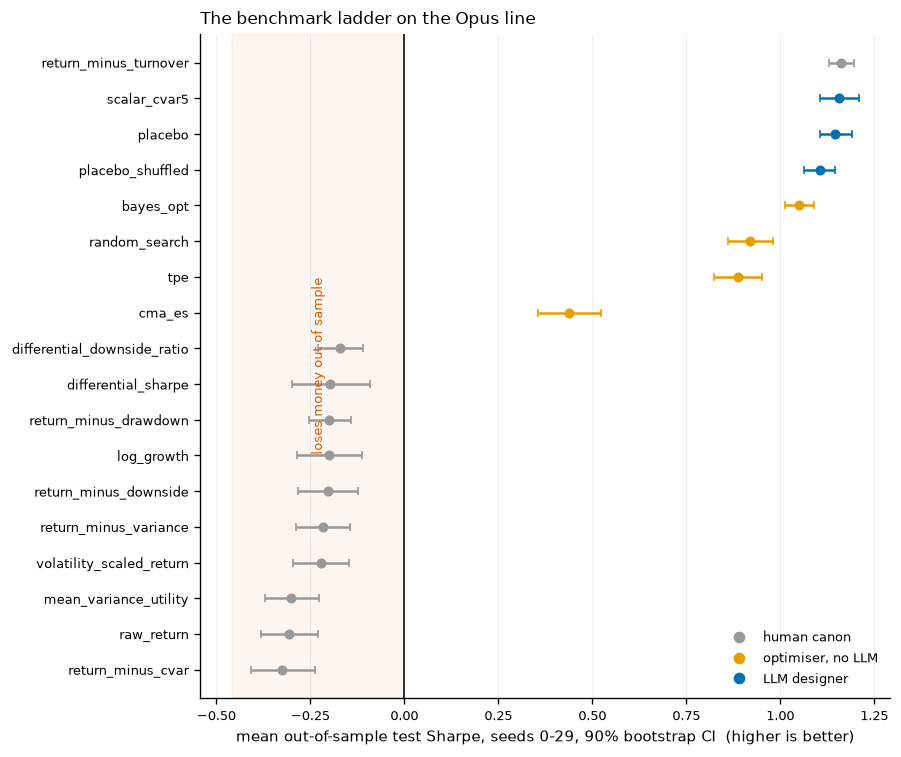

arm                            kind                   n  mean Sharpe [90% CI]
----------------------------------------------------------------------------------
return_minus_turnover          human canon           30  +1.1609 [+1.1286, +1.1961]
scalar_cvar5                   LLM designer          30  +1.1558 [+1.1061, +1.2083]
placebo                        LLM designer          30  +1.1454 [+1.1053, +1.1900]
placebo_shuffled               LLM designer          30  +1.1047 [+1.0640, +1.1458]
bayes_opt                      optimiser, no LLM     30  +1.0503 [+1.0131, +1.0894]
random_search                  optimiser, no LLM     30  +0.9203 [+0.8609, +0.9794]
tpe                            optimiser, no LLM     30  +0.8876 [+0.8243, +0.9520]
cma_es                         optimiser, no LLM     30  +0.4391 [+0.3560, +0.5241]
differential_downside_ratio    human canon           30  -0.1710 [-0.2306, -0.1093]
differential_sharpe            human canon           30  -0.1973 [-0.2996, -0.0900]

In [12]:
KIND = {}
for _, arm in [k for k in CELLS if k[0] == "test"]:
    if arm.startswith("baseline_"):
        KIND[arm] = ("human canon", OKABE_ITO["grey"])
    elif arm in ("random_search", "bayes_opt", "cma_es", "tpe"):
        KIND[arm] = ("optimiser, no LLM", OKABE_ITO["orange"])
    else:
        KIND[arm] = ("LLM designer", OKABE_ITO["blue"])

lad = []
for (line, arm), per in CELLS.items():
    if line != "test":
        continue
    v = np.array([per[s][0] for s in sorted(per) if s < FLOOR], float)
    if v.size < 5:
        continue
    m, lo, hi = boot_ci(v)
    lad.append((arm.replace("baseline_", ""), KIND[arm][0], KIND[arm][1], m, lo, hi, v.size))
lad.sort(key=lambda t: t[3])

fig, ax = plt.subplots(figsize=(7.4, 6.2))
for i, (name, kind, col, m, lo, hi, n) in enumerate(lad):
    ax.errorbar(m, i, xerr=[[m - lo], [hi - m]], fmt="o", color=col, ecolor=col,
                elinewidth=1.5, capsize=2.5, markersize=5, zorder=3)
ax.axvline(0.0, color="0.2", lw=1.2)
xlo6 = min(t[4] for t in lad) - 0.05
ax.axvspan(xlo6, 0.0, color=OKABE_ITO["vermillion"], alpha=0.06, zorder=0)
ax.text(xlo6 / 2, (len(lad) - 1) / 2, "loses money out of sample", rotation=90,
        ha="center", va="center", fontsize=8, color=OKABE_ITO["vermillion"])

ax.set_yticks(np.arange(len(lad)))
ax.set_yticklabels(["%s" % t[0] for t in lad])
ax.set_ylim(-0.8, len(lad) - 0.2)
ax.set_xlabel("mean out-of-sample test Sharpe, seeds 0-29, 90% bootstrap CI  (higher is better)")
ax.set_title("The benchmark ladder on the Opus line", loc="left")
seen = {}
for _, kind, col, *_ in lad:
    seen[kind] = col
handles = [plt.Line2D([], [], marker="o", ls="none", color=c, label=k) for k, c in seen.items()]
ax.legend(handles=handles, loc="lower right")
ax.grid(axis="y", visible=False)
savefig(fig, FIGDIR / "F6_benchmark_ladder.png")
plt.show()

print("%-30s %-18s %5s  %s" % ("arm", "kind", "n", "mean Sharpe [90% CI]"))
print("-" * 82)
for name, kind, _c, m, lo, hi, n in reversed(lad):
    print("%-30s %-18s %5d  %+7.4f [%+7.4f, %+7.4f]" % (name, kind, n, m, lo, hi))

**Figure 6. Every arm on the Opus line at thirty seeds, ranked, with ninety per cent intervals.**
Grey is a human-written objective from the literature, orange a derivative-free optimiser with no
language model, blue a language-model designer. The `distributional` and `scalar` rows are absent
because their jobs are still running.

**What to conclude.** The separation is not marginal. Ten of the eleven human objectives sit
below zero, meaning they lost money out of sample, while every automated arm sits above 0.4. The
gap between the worst automated arm and the best of those ten is roughly six tenths of a Sharpe
unit, far outside the intervals.

### The one result that does not fit, and it is the most interesting row here

**`return_minus_turnover` is the best arm on the entire panel**, statistically tied with the best
language-model arms, while the other ten human objectives are the worst. It is also the only one
of the eleven that penalises trading.

The environment charges a transaction cost on every rebalance. A coherent reading is that the
other ten objectives reward gross performance and trade themselves into the ground paying for it,
while this one does not. **That is a hypothesis, not a finding.** It predicts something testable:
the ten losing arms should show high realised turnover and the winner low. The turnover series is
recorded per run, so the check is cheap, and it is now an obligation rather than an option.

**A second surprise worth naming rather than smoothing over.** `return_minus_cvar` is last. The
objective explicitly built to control tail loss has neither the best Sharpe nor the best CVaR.
Reporting that flatly, and investigating it, is worth more than a tidy table.

**The honest limit on this comparison.** The baselines are fixed objectives evaluated once, while
the automated arms are the *winners* of a thirty-candidate search. Some of the gap is selection.
The optimiser arms exist precisely to price that, since they get the same budget without a
language model, and they land below the language-model arms but far above the canon.

## 9. The whole picture in one panel

**Every model, every arm, one number each.** This is the exhibit to look at if you want to see
where the variation actually lives.

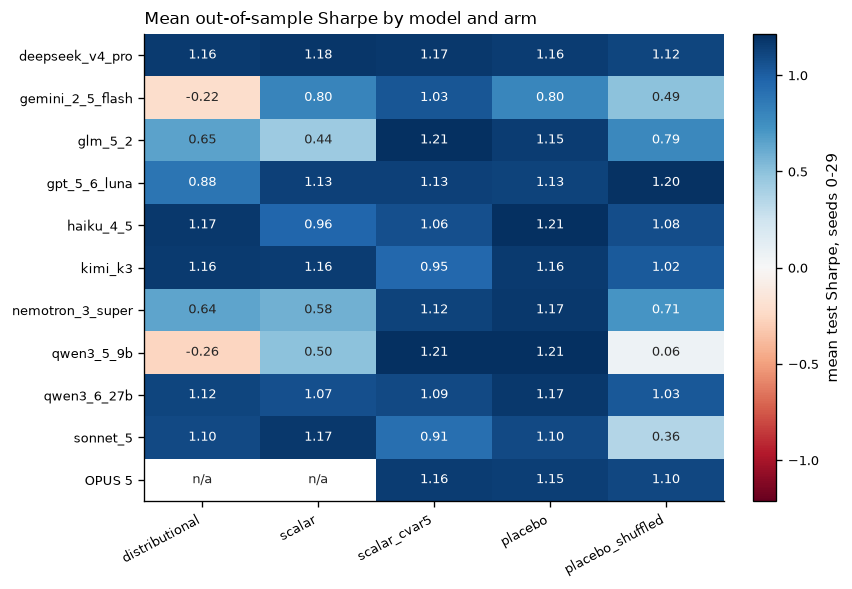

In [13]:
ARMS5 = ["distributional", "scalar", "scalar_cvar5", "placebo", "placebo_shuffled"]
rows_hm, labels_hm = [], []
for line in LEGS + ["test"]:
    row = []
    for arm in ARMS5:
        per = CELLS.get((line, arm))
        v = [per[s][0] for s in sorted(per) if s < FLOOR] if per else []
        row.append(float(np.mean(v)) if len(v) >= 5 else np.nan)
    if not all(np.isnan(row)):
        rows_hm.append(row)
        labels_hm.append("OPUS 5" if line == "test" else pretty(line))

M = np.array(rows_hm)
fig, ax = plt.subplots(figsize=(7.0, 4.8))
vmax = np.nanmax(np.abs(M))
im = ax.imshow(M, cmap="RdBu", vmin=-vmax, vmax=vmax, aspect="auto")
ax.set_xticks(range(len(ARMS5)))
ax.set_xticklabels(ARMS5, rotation=28, ha="right")
ax.set_yticks(range(len(labels_hm))); ax.set_yticklabels(labels_hm)
for i in range(M.shape[0]):
    for j in range(M.shape[1]):
        v = M[i, j]
        ax.text(j, i, "n/a" if np.isnan(v) else "%.2f" % v, ha="center", va="center",
                fontsize=7.5, color="0.15" if (np.isnan(v) or abs(v) < vmax * 0.55) else "white")
fig.colorbar(im, ax=ax, label="mean test Sharpe, seeds 0-29")
ax.set_title("Mean out-of-sample Sharpe by model and arm", loc="left")
ax.grid(False)
savefig(fig, FIGDIR / "F7_model_arm_heatmap.png")
plt.show()

**Figure 7. Mean out-of-sample Sharpe for every model and arm at thirty seeds.** Blue is higher,
red lower, and the scale is symmetric about zero so the sign is readable at a glance. Cells marked
`n/a` have no data yet.

**What to conclude first.** Most of the grid is a fairly uniform blue a little above one, which
says something important and easy to miss: **the machine works.** A language model handed a
reward-design task, in almost every configuration on almost every model, produces reward code that
trains a profitable out-of-sample allocator. The failures are the exception and they are localised.

**The variation concentrates in one column.** `distributional` holds both negative cells. Nothing
else in the grid goes below zero.

In [14]:
# The controls carry their own argument, so they are MEASURED rather than eyeballed off the grid.
print("CONTROL CONTRASTS, paired, seeds 0-%d, %d%% CI" % (FLOOR - 1, round((1 - CI_ALPHA) * 100)))
print()
print("C1. placebo minus scalar      = does MORE TEXT alone help, with no information in it?")
print("%-20s %-26s %s" % ("model", "d Sharpe [90% CI]", "verdict"))
print("-" * 74)
n_pos = 0
for line in sorted(LEGS):
    d = paired(line, "placebo", "scalar", 0, FLOOR)
    if d.size < 5:
        continue
    m, lo, hi = boot_ci(d)
    v = "inert block HELPS" if lo > 0 else ("inert block HURTS" if hi < 0 else "no difference")
    n_pos += int(lo > 0)
    print("%-20s %+7.4f [%+7.4f,%+7.4f]   %s" % (pretty(line), m, lo, hi, v))
print("   -> the inert block significantly HELPED on %d of %d models" % (n_pos, len(LEGS)))

print()
print("C2. placebo_shuffled versus the other two controls: is it the WEAKEST on each model?")
weakest = 0
tot = 0
for line in sorted(LEGS):
    vals = {}
    for arm in ("scalar_cvar5", "placebo", "placebo_shuffled"):
        per = CELLS.get((line, arm))
        v = [per[s][0] for s in sorted(per) if s < FLOOR] if per else []
        if len(v) >= 5:
            vals[arm] = float(np.mean(v))
    if len(vals) == 3:
        tot += 1
        is_min = min(vals, key=vals.get) == "placebo_shuffled"
        weakest += int(is_min)
        print("   %-20s %s   %s" % (pretty(line),
              "  ".join("%s=%+0.3f" % (a.replace("placebo_shuffled", "shuf")[:12], vals[a]) for a in vals),
              "<- shuffled weakest" if is_min else ""))
print("   -> deranged values were the weakest control on %d of %d models" % (weakest, tot))

CONTROL CONTRASTS, paired, seeds 0-29, 90% CI

C1. placebo minus scalar      = does MORE TEXT alone help, with no information in it?
model                d Sharpe [90% CI]          verdict
--------------------------------------------------------------------------
deepseek_v4_pro      -0.0226 [-0.0503,+0.0066]   no difference
gemini_2_5_flash     -0.0028 [-0.0580,+0.0502]   no difference
glm_5_2              +0.7092 [+0.6042,+0.8132]   inert block HELPS
gpt_5_6_luna         -0.0031 [-0.0418,+0.0359]   no difference
haiku_4_5            +0.2444 [+0.2027,+0.2868]   inert block HELPS
kimi_k3              +0.0086 [-0.0313,+0.0512]   no difference
nemotron_3_super     +0.5880 [+0.5088,+0.6725]   inert block HELPS
qwen3_5_9b           +0.7081 [+0.6435,+0.7766]   inert block HELPS
qwen3_6_27b          +0.0977 [+0.0496,+0.1520]   inert block HELPS
sonnet_5             -0.0690 [-0.1072,-0.0314]   inert block HURTS
   -> the inert block significantly HELPED on 5 of 10 models

C2. placebo_shuffled

**What the controls actually show, and one of these was not what I expected.**

**Deranged values are the weakest control on most but not all models.** Where the structure of the
tail block is preserved and the numbers inside it are scrambled, outcomes are usually the worst of
the three controls. That is consistent with wrong numbers actively misleading a designer rather
than being ignored, which is a stronger statement than saying tail content simply fails to help.

**More text with no information in it is not neutral.** On several models the `placebo` arm, which
is the scalar number plus an inert block of matched length, significantly *beats* plain `scalar`.
That is a format or length effect, not an information effect, and it is exactly the confound this
control exists to expose.

**It also sharpens what the headline contrast can claim.** `distributional` differs from `scalar`
in two ways at once: it carries tail information, and it is longer and more structured. The
`placebo` result shows the second difference is not inert. Any account of the main effect has to
sit alongside the fact that a matched-length block of nothing changes behaviour on some models.
**That is a limitation of the arm design surfaced by the design's own control, which is what a
control is for.**

## 10. What this notebook does not establish

**Being explicit here is worth more than any additional analysis.** Every item below is a real
limit on what may be claimed from the evidence above.

1. **No confirmatory result exists yet.** The single arm the pre-registration permits as the
   study's finding has zero records. Everything shown is report-only.
2. **These are not the registered estimators.** The frozen plan uses deflated Sharpe rather than
   raw Sharpe, interquartile means rather than means, seed-block bootstrap rather than the simple
   bootstrap here, and a formal equivalence test. Point estimates and intervals will move.
3. **The registered equivalence margin is not drawn on any figure, deliberately.** The margin is
   0.05 in *deflated* Sharpe units and these axes are raw Sharpe. Shading a band of the right
   number in the wrong units would look rigorous and be wrong.
4. **The reported rung is zero, so nothing here is banked.** Results above the banked rung are
   real and stored, and they count in full once the rung beneath them closes.
5. **Thirty seeds is not enough to declare equivalence.** The power analysis puts the requirement
   at roughly one hundred and seventy-three seeds at the registered margin.
6. **The human canon is evaluated once, the automated arms are search winners.** Part of the H1
   gap is selection rather than authorship, and the optimiser arms are the instrument that prices
   it.
7. **Two mechanism claims here are hypotheses, not findings.** The turnover explanation for
   `return_minus_turnover` and the capability explanation for the Qwen split both make testable
   predictions and neither has been tested in this notebook.
8. **No multiplicity correction is applied outside the ten-leg family.** The benchmark ladder and
   the heatmap are descriptive.

## Appendix. Full numeric tables

Everything plotted above, printed, so any figure can be checked against the numbers behind it.

In [15]:
print("A1. H2 PAIRED CONTRAST, seeds 0-%d, both co-primary metrics" % (FLOOR - 1))
print("%-20s %3s  %-24s %7s %7s  %-26s %7s" %
      ("model", "n", "d Sharpe [90% CI]", "p", "q", "d CVaR-5% [90% CI]", "q"))
print("-" * 110)
for r in res:
    print("%-20s %3d  %+6.3f [%+6.3f,%+6.3f] %7.4f %7.4f  %+8.5f [%+8.5f,%+8.5f] %7.4f"
          % (r["line"], r["n"], r["sh"], r["sh_lo"], r["sh_hi"], r["sh_p"], r["sh_q"],
             r["cv"], r["cv_lo"], r["cv_hi"], r["cv_q"]))

print()
print("A2. EVERY CELL: mean test Sharpe at seeds 0-%d  (n/a = fewer than 5 seeds)" % (FLOOR - 1))
print("%-22s %s" % ("model", "".join("%16s" % a[:15] for a in ARMS5)))
print("-" * (22 + 16 * len(ARMS5)))
for lbl, row in zip(labels_hm, rows_hm):
    print("%-22s %s" % (lbl, "".join("%16s" % ("n/a" if np.isnan(v) else "%+.4f" % v) for v in row)))

print()
print("A3. DEPTH: records held per REGISTERED arm  (0 = the arm exists in the design but has no data)")
for line in LINES:
    print("  %s" % pretty(line))
    for arm in roster(line):
        n = depth(line, arm)
        flag = "   <-- NO DATA" if n == 0 else ""
        print("      %-40s %5d%s" % (arm, n, flag))

print()
print("figures written to:", FIGDIR)
for p in sorted(FIGDIR.glob("*.png")):
    print("   ", p.name)

A1. H2 PAIRED CONTRAST, seeds 0-29, both co-primary metrics
model                  n  d Sharpe [90% CI]              p       q  d CVaR-5% [90% CI]               q
--------------------------------------------------------------------------------------------------------------
gemini_2_5_flash      30  -1.015 [-1.112,-0.914]  0.0001  0.0002  -0.00770 [-0.00862,-0.00675]  0.0002
qwen3_5_9b            30  -0.759 [-0.846,-0.677]  0.0001  0.0002  -0.00355 [-0.00400,-0.00308]  0.0002
gpt_5_6_luna          30  -0.247 [-0.308,-0.186]  0.0001  0.0002  +0.00355 [+0.00262,+0.00449]  0.0002
sonnet_5              30  -0.069 [-0.110,-0.030]  0.0106  0.0212  +0.00006 [-0.00042,+0.00056]  0.8476
deepseek_v4_pro       30  -0.015 [-0.041,+0.011]  0.3548  0.4146  -0.00008 [-0.00058,+0.00039]  0.8476
kimi_k3               30  +0.003 [-0.039,+0.049]  0.9229  0.9229  +0.00042 [-0.00010,+0.00093]  0.2887
qwen3_6_27b           30  +0.046 [-0.019,+0.108]  0.2602  0.3717  +0.00061 [-0.00002,+0.00123]  0.2141
nemot

## What happens next

**The confirmatory arm closes the floor, and then the whole fleet climbs together.**

1. The Opus H2 pair test finishes and rung 30 banks. That is the first reportable result the
   campaign will have produced, and it fills section 4 and the reserved rows in Figures 2 and 3.
2. Opus joins the other models on the ladder toward rung 100 and rung 189. Figure 5 is the reason
   this matters more than it might appear.
3. The registered analysis runs, replacing every descriptive estimator here with the frozen ones.
4. Two mechanism checks become due: turnover against the canon ranking, and the responsiveness
   and mediation instruments against the capability story.

**To refresh this notebook**, set `FORCE_RELOAD = True` in the setup cell and run all cells. Every
figure, table and placeholder updates from the archive.